In [1]:
import sys, itertools, time
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "test_idx": t}
    for s, t in itertools.product([42, 123, 7], [0, 1, 2])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

# Physics Constraint Comparison: Darcy Continuous

- PDE: $-\nabla \cdot (a \nabla u) = 10$, continuous coefficient function
- Latent dimension: $d = 6$
- Physics term: weak PDE residual at fixed collocation points

In [2]:
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
from numpyro.diagnostics import effective_sample_size, split_gelman_rubin

from src.problems.darcy_continuous import (
    DarcyContinuous,
    mollifier,
    compute_pde_residual_single_sample,
)
from src.evaluation.metrics import rmse
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95, nll_score,
    compute_prior_predictive, build_prior_result,
    plot_field_comparison, plot_calibration, plot_posterior_gallery,
    plot_posterior_predictive, plot_trace, plot_metrics_table,
    plot_rho_sweep, plot_std_comparison, plot_metrics_comparison_table,
    plot_sharpness_calibration_tradeoff,
    bootstrap_metric_ci, compute_per_chain_metrics,
    bootstrap_metric_difference_ci, format_significance_table,
    compute_sigma_from_map, tune_sigma, recommended_nuts_config, mcmc_reliability_flag,
    chi2_ppc,
    compute_metric_convergence, plot_metric_convergence,
    load_problem, get_nf_mode, make_log_prior,
    make_gaussian_log_likelihood, make_numpyro_model, make_numpyro_model_physics,
    run_map_estimation, compute_sigma_from_map_residual,
    sample_unconditional_prior, decode_posterior_batched,
    run_mcmc, extract_mcmc_diagnostics,
    compute_standard_metrics, compute_bootstrap_ci_block,
    build_mcmc_result, save_experiment_result,
    print_per_chain_table, print_dimension_diagnostics, print_cross_seed_summary,
    compute_error_std_correlation,
    load_cross_seed_results, cross_seed_metric_summary,
    _use_science_style,
)

SEEDS = [42, 123, 7]
if _task_id is not None:
    SEEDS = [PARAMETER_GRID[_task_id]["seed"]]

TEST_IDX = 0
if _task_id is not None:
    TEST_IDX = PARAMETER_GRID[_task_id]["test_idx"]

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35, NumPyro: 0.19.0


Devices: [CudaDevice(id=0)]


## 1. Load Trained Model

In [3]:
CHECKPOINT_PATH = Path("../runs/final_darcy_continuous/weights/best.pt")
TEST_DATA_PATH = "../data/darcy_continuous/smh_test_in.mat"

problem = DarcyContinuous(seed=42, test_data_path=TEST_DATA_PATH)
params = load_problem(problem, CHECKPOINT_PATH)
beta_mode, d = get_nf_mode(problem, params)
log_prior_fn = make_log_prior(problem, params)

n_points = problem.get_n_points()

print(f"Latent dim: {problem.BETA_SIZE}")

Loading data...


  Test: a=(200, 841, 1), u=(200, 841, 1)
Setting up grids and test functions...


  int_grid: (45, 2), v: (45, 1)
Building models...


  Initialized enc: 116,038 params


  Initialized u: 102,006 params
  Initialized a: 102,006 params


E0612 13:04:38.221683      23 hlo_lexer.cc:443] Failed to parse int literal: 894515288310727292233


  Initialized nf: 10,280 params
Loading checkpoint: ../runs/final_darcy_continuous/weights/best.pt
  Loaded enc
  Loaded u
  Loaded a
  Loaded nf


Latent dim: 6


## 2. Config

In [4]:
N_OBS = 100
NC_PDE = 50

RHO_PDE_VALUES = [2.0, 1.0, 0.5, 0.3, 0.15, 0.1, 0.07, 0.05]
SWEEP_WARMUP = 1000
SWEEP_SAMPLES = 500

NUM_WARMUP = 5000
NUM_SAMPLES = 2000
NUM_CHAINS = 4
CHAIN_METHOD = 'vectorized'

inv_config = InversionConfig(
    epochs=200,
    loss_weights=LossWeights(pde=1.0, data=50.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.01),
    scheduler=SchedulerConfig(type='StepLR', step_size=25, gamma=0.8),
)

## 3. Fixed PDE Collocation Points

In [5]:
pde_rng = random.PRNGKey(123)
xc_fixed, R_fixed = problem.genPoint.weight_centers(
    n_center=NC_PDE, R_max=1e-4, R_min=1e-4, key=pde_rng,
)
x_pde_fixed = (problem.int_grid[None, :, :] * R_fixed + xc_fixed).reshape(-1, 2)

print(f"Fixed PDE grid: {x_pde_fixed.shape}  ({NC_PDE} centers x {problem.n_grid} pts)")


def log_pde_fn(beta, rho_pde):
    """PDE virtual-observable log-likelihood with fixed collocation points."""
    beta_b = beta[None, :]
    x_pde_b = x_pde_fixed[None, :, :]
    a_decoded = problem.models['a'].apply({'params': params['a']}, x_pde_b, beta_b)
    a_vals = a_decoded[0, :, None]
    residuals = compute_pde_residual_single_sample(
        params['u'], problem.models['u'], beta,
        xc_fixed, R_fixed, problem.int_grid, problem.v, problem.dv_dr,
        a_vals, problem.n_grid,
    )
    return -0.5 * jnp.sum(residuals ** 2) / (rho_pde ** 2)

Fixed PDE grid: (2250, 2)  (50 centers x 45 pts)


## 4. Sigma Tuning (seed-42 observations)

In [6]:
_rng_setup = random.PRNGKey(42)
_rng_setup, _key = random.split(_rng_setup)

_obs_indices_tune = problem.sample_observation_indices(n_points, N_OBS, 'random', _key)
_obs_data_tune = problem.prepare_observations(
    sample_indices=[TEST_IDX], obs_indices=_obs_indices_tune,
)
_x_full_tune = _obs_data_tune['x_full']
_x_obs_tune = _obs_data_tune['x_obs']
_u_obs_tune = _obs_data_tune['u_obs']
_a_true_tune = _obs_data_tune['a_true']

_log_lik_tune = make_gaussian_log_likelihood(problem, params, mollifier, _x_obs_tune, _u_obs_tune)
_numpyro_model_tune = make_numpyro_model(d, log_prior_fn, _log_lik_tune)


def _model_factory_tune(sigma):
    def _model():
        _numpyro_model_tune(sigma=sigma)
    return _model


def _decode_fn_tune(beta_samples):
    a_preds = []
    for i in range(len(beta_samples)):
        beta_i = beta_samples[i:i+1]
        preds = problem.predict_from_beta(params, jnp.array(beta_i), _x_full_tune)
        a_preds.append(np.array(preds['a_pred'][0, :, 0]))
    return np.stack(a_preds)


_rng_setup, _tune_key = random.split(_rng_setup)
SIGMA, _ = tune_sigma(
    model_fn_factory=_model_factory_tune,
    beta_mode=beta_mode,
    sigma_candidates=[0.005, 0.01, 0.02, 0.04, 0.08, 0.15],
    rng_key=_tune_key,
    decode_fn=_decode_fn_tune,
    a_true=np.array(_a_true_tune[0, :, 0]),
    pilot_warmup=2000,
    pilot_samples=500,
    pilot_chains=2,
)
print(f"Sigma (tuned, seed-42): {SIGMA:.6f}")

  Sigma tuning (6 candidates, 2000 warmup + 500 samples × 2 chains):


    sigma=0.0050  cov=0.998  ESS_min=128.8  R-hat=1.011  div=0  OK


    sigma=0.0100  cov=0.998  ESS_min=141.1  R-hat=1.018  div=0  OK


    sigma=0.0200  cov=1.000  ESS_min=97.0  R-hat=1.009  div=0  OK


    sigma=0.0400  cov=1.000  ESS_min=30.2  R-hat=1.057  div=1  OK


    sigma=0.0800  cov=0.999  ESS_min=2.5  R-hat=1.309  div=5  LOW-ESS


    sigma=0.1500  cov=0.999  ESS_min=5.6  R-hat=1.142  div=3  LOW-ESS
  Selected sigma=0.005  (coverage=0.998, ESS_min=128.8)
Sigma (tuned, seed-42): 0.005000


## 5. rho_pde Sweep (outside seed loop)

In [7]:
_rng_setup, _sweep_do_key = random.split(_rng_setup)
nuts_cfg_sweep = recommended_nuts_config(problem.BETA_SIZE, SIGMA)
_kernel_sweep_do = NUTS(
    _numpyro_model_tune,
    init_strategy=init_to_value(values={"beta": beta_mode}),
    target_accept_prob=nuts_cfg_sweep['target_accept_prob'],
    max_tree_depth=nuts_cfg_sweep['max_tree_depth'],
    dense_mass=nuts_cfg_sweep.get('dense_mass', False),
)
_mcmc_sweep_do = MCMC(_kernel_sweep_do, num_warmup=SWEEP_WARMUP, num_samples=SWEEP_SAMPLES,
                      num_chains=1, progress_bar=True)
_mcmc_sweep_do.run(_sweep_do_key, sigma=SIGMA, extra_fields=('diverging',))

_beta_sweep_do = _mcmc_sweep_do.get_samples()["beta"]
_n_sweep_do = _beta_sweep_do.shape[0]
_x_tile_sweep = jnp.tile(_x_full_tune, (_n_sweep_do, 1, 1))
_a_pred_sweep_do = problem.models['a'].apply({'params': params['a']}, _x_tile_sweep, _beta_sweep_do)
_a_pred_sweep_do = _a_pred_sweep_do[..., None] if _a_pred_sweep_do.ndim == 2 else _a_pred_sweep_do
_a_mean_sweep_do = jnp.mean(_a_pred_sweep_do, axis=0)
_a_err_sweep_do = float(
    jnp.linalg.norm(_a_mean_sweep_do[:, 0] - _a_true_tune[0, :, 0]) /
    jnp.linalg.norm(_a_true_tune[0, :, 0])
)
_a_lo_sweep_do = jnp.percentile(_a_pred_sweep_do, 2.5, axis=0)
_a_hi_sweep_do = jnp.percentile(_a_pred_sweep_do, 97.5, axis=0)
_coverage_sweep_do = float(((jnp.array(_a_true_tune[0]) >= _a_lo_sweep_do) & (jnp.array(_a_true_tune[0]) <= _a_hi_sweep_do)).mean())
_ci_width_sweep_do = float(jnp.mean(_a_hi_sweep_do - _a_lo_sweep_do))
_mean_std_sweep_do = float(jnp.mean(jnp.std(_a_pred_sweep_do[:, :, 0], axis=0)))
_sweep_data_only_baseline = {
    'a_err': _a_err_sweep_do,
    'coverage': _coverage_sweep_do,
    'ci_width': _ci_width_sweep_do,
    'mean_std': _mean_std_sweep_do,
}
print(f"Sweep data-only baseline a_err = {_a_err_sweep_do:.4f}")

  0%|          | 0/1500 [00:00<?, ?it/s]

warmup:   0%|          | 1/1500 [00:04<2:00:46,  4.83s/it, 1 steps of size 1.78e+00. acc. prob=0.00]

warmup:   1%|▏         | 20/1500 [00:04<04:21,  5.65it/s, 3 steps of size 1.16e-03. acc. prob=0.80] 

warmup:   2%|▏         | 32/1500 [00:05<02:26, 10.01it/s, 127 steps of size 6.69e-04. acc. prob=0.84]

warmup:   3%|▎         | 43/1500 [00:06<02:56,  8.27it/s, 511 steps of size 6.18e-05. acc. prob=0.84]

...

sample:  99%|█████████▉| 1486/1500 [00:36<00:00, 59.97it/s, 31 steps of size 1.11e-01. acc. prob=0.97]

sample: 100%|█████████▉| 1493/1500 [00:36<00:00, 61.88it/s, 31 steps of size 1.11e-01. acc. prob=0.97]

sample: 100%|██████████| 1500/1500 [00:36<00:00, 62.09it/s, 31 steps of size 1.11e-01. acc. prob=0.97]

sample: 100%|██████████| 1500/1500 [00:36<00:00, 41.26it/s, 31 steps of size 1.11e-01. acc. prob=0.97]

Sweep data-only baseline a_err = 0.0024


In [8]:
_numpyro_model_physics_sweep = make_numpyro_model_physics(d, log_prior_fn, _log_lik_tune, log_pde_fn)


def _run_sweep_one(rho_pde, warmup, n_samples, rng_key):
    """Run NUTS for one rho_pde value (using tuning obs), return metrics dict."""
    nuts_cfg = recommended_nuts_config(problem.BETA_SIZE, SIGMA)
    kernel = NUTS(
        _numpyro_model_physics_sweep,
        init_strategy=init_to_value(values={"beta": beta_mode}),
        target_accept_prob=nuts_cfg['target_accept_prob'],
        max_tree_depth=nuts_cfg['max_tree_depth'],
        dense_mass=nuts_cfg.get('dense_mass', False),
    )
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=n_samples,
                num_chains=1, chain_method=CHAIN_METHOD, progress_bar=True)
    _t_pilot = time.time()
    mcmc.run(rng_key, sigma=SIGMA, rho_pde=rho_pde, extra_fields=('diverging',))
    print(f"  Pilot completed in {time.time() - _t_pilot:.1f}s")

    beta_s = mcmc.get_samples()["beta"]
    n_div = int(mcmc.get_extra_fields()['diverging'].sum())

    beta_by_chain = np.array(beta_s)[None, :, :]
    ess_min = float(effective_sample_size(beta_by_chain).min())

    _a_true_np_t = np.array(_a_true_tune[0, :, 0])
    a_pred_all, u_pred_all = decode_posterior_batched(problem, params, beta_s, _x_full_tune)

    a_mean = np.mean(a_pred_all, axis=0)
    a_err = float(np.linalg.norm(a_mean - _a_true_np_t) / (np.linalg.norm(_a_true_np_t) + 1e-12))

    u_true_tune = np.array(_obs_data_tune['u_true'][0, :, 0])
    u_mean = np.mean(u_pred_all, axis=0)
    u_err = float(np.linalg.norm(u_mean - u_true_tune) / (np.linalg.norm(u_true_tune) + 1e-12))

    metrics = compute_standard_metrics(a_pred_all, _a_true_np_t)
    flag, _ = mcmc_reliability_flag(ess_min, 1.0, n_div, n_samples)

    return {
        "rho_pde": rho_pde,
        "a_err": a_err,
        "u_err": u_err,
        "coverage": metrics['coverage_95'],
        "ess_min": ess_min,
        "n_div": n_div,
        "crps_a": metrics['crps_a'],
        "nll_a": metrics['nll_a'],
        "ci_width": metrics['ci_width'],
        "mean_std": metrics['mean_std'],
        "rhat_max": None,
        "rhat_mean": None,
        "reliability_flag": flag,
    }

In [9]:
print(f"Screening sweep: {SWEEP_WARMUP} warmup, {SWEEP_SAMPLES} samples per rho")
print(f"rho values: {RHO_PDE_VALUES}")

sweep_results = []
for rho in RHO_PDE_VALUES:
    print(f"\n{'='*60}")
    print(f"rho_pde = {rho}")
    print(f"{'='*60}")
    _rng_setup, key = random.split(_rng_setup)
    res = _run_sweep_one(rho, SWEEP_WARMUP, SWEEP_SAMPLES, key)
    sweep_results.append(res)
    print(f"  a_err={res['a_err']:.4f}  u_err={res['u_err']:.4f}  "
          f"coverage={res['coverage']:.2%}  ESS_min={res['ess_min']:.1f}  "
          f"n_div={res['n_div']}  CRPS_a={res['crps_a']:.6f}")

Screening sweep: 1000 warmup, 500 samples per rho
rho values: [2.0, 1.0, 0.5, 0.3, 0.15, 0.1, 0.07, 0.05]

rho_pde = 2.0


  0%|          | 0/1500 [00:00<?, ?it/s]

warmup:   0%|          | 1/1500 [00:07<3:11:48,  7.68s/it, 1 steps of size 1.78e+00. acc. prob=0.00]

warmup:   1%|          | 12/1500 [00:07<12:02,  2.06it/s, 255 steps of size 4.23e-04. acc. prob=0.68]

warmup:   1%|          | 15/1500 [00:08<09:03,  2.73it/s, 15 steps of size 7.53e-04. acc. prob=0.75] 

...

sample:  99%|█████████▉| 1489/1500 [00:45<00:00, 82.90it/s, 15 steps of size 3.31e-01. acc. prob=0.95]

sample: 100%|█████████▉| 1499/1500 [00:45<00:00, 85.45it/s, 15 steps of size 3.31e-01. acc. prob=0.95]

sample: 100%|██████████| 1500/1500 [00:45<00:00, 33.07it/s, 7 steps of size 3.31e-01. acc. prob=0.95] 

  Pilot completed in 46.4s


  a_err=0.0015  u_err=0.0027  coverage=97.98%  ESS_min=279.7  n_div=0  CRPS_a=0.002539


In [10]:
header = f"{'rho_pde':>10} {'a_err':>8} {'u_err':>8} {'coverage':>10} {'ESS_min':>9} {'n_div':>6} {'CRPS_a':>10}"
print(header)
print("-" * len(header))
print(f"{'inf (DO)':>10}  {_a_err_sweep_do:>7.4f}  {'N/A':>7}  {'N/A':>9}  {'N/A':>8}  {'N/A':>5}  {'N/A':>9}")
for r in sweep_results:
    print(f"{r['rho_pde']:>10.2f}  {r['a_err']:>7.4f}  {r['u_err']:>7.4f}  "
          f"{r['coverage']:>9.2%}  {r['ess_min']:>8.1f}  {r['n_div']:>5}  {r['crps_a']:>9.6f}")

   rho_pde    a_err    u_err   coverage   ESS_min  n_div     CRPS_a
-------------------------------------------------------------------
  inf (DO)   0.0024      N/A        N/A       N/A    N/A        N/A
      2.00   0.0019   0.0029     99.76%      95.3      1   0.003126
      1.00   0.0021   0.0029     99.76%      87.5      0   0.003257
      0.50   0.0019   0.0029     99.76%      53.1      0   0.002982
      0.30   0.0019   0.0028     99.76%      84.7      0   0.003086
      0.15   0.0016   0.0028     99.76%      71.8      0   0.002770
      0.10   0.0016   0.0028     99.52%     201.5      0   0.002722
      0.07   0.0015   0.0028     99.52%     133.8      0   0.002645
      0.05   0.0015   0.0027     97.98%     279.7      0   0.002539


In [11]:
_a_err_threshold = _a_err_sweep_do * 2
candidates = [(abs(r['coverage'] - 0.95), r) for r in sweep_results
              if r['a_err'] <= _a_err_threshold]

if candidates:
    candidates.sort(key=lambda x: x[0])
    _best = candidates[0][1]
    BEST_RHO_PDE = _best['rho_pde']
    print(f"Best rho_pde = {BEST_RHO_PDE}")
    print(f"  a_err    = {_best['a_err']:.4f}  (baseline: {_a_err_sweep_do:.4f})")
    print(f"  coverage = {_best['coverage']:.2%}  (ideal: 95%)")
else:
    print("No candidate with a_err <= 2x baseline.")
    print("Setting BEST_RHO_PDE to largest value (weakest physics).")
    BEST_RHO_PDE = max(RHO_PDE_VALUES)

print(f"\nBEST_RHO_PDE = {BEST_RHO_PDE}")

Best rho_pde = 0.05
  a_err    = 0.0015  (baseline: 0.0024)
  coverage = 97.98%  (ideal: 95%)

BEST_RHO_PDE = 0.05


## 6. Multi-Seed Loop


SEED = 42


Prior predictive: a_err=0.3443, CRPS=0.4550, cov95=0.9287


  Inversion grid: n_mesh_or_grid=7, n_grid=25


Loss weights: pde=1.0, data=50.0, target=u


Inverting:   0%|          | 0/200 [00:00<?, ?it/s]

...

sample: 100%|██████████| 2000/2000 [1:11:56<00:00,  2.16s/it]

sample: 100%|██████████| 2000/2000 [1:11:56<00:00,  2.16s/it]

MCMC warmup: 10762.8s, sampling: 4316.3s
ESS min=2.0, R-hat max=22.1386, divergences=0/8000, [FAIL] ESS_min=2.0 < 10; R-hat_max=22.139 > 1.2


Physics: a_err=0.0614  u_err=0.0483  coverage=99.76%  CRPS=0.033504
  Chi2 PPC (data-only): chi2=0.22, p=1.0000
  Chi2 PPC (physics):   chi2=465.67, p=0.0000
Saved structured result to: /workspace/experiments/results/structured/physics/darcy_continuous_2026-06-12T19-38-29_seed42_test1.json

  Darcy Continuous seed=42 (sigma=0.005, rho_pde=0.05)
  Metric                           Data-Only      Physics-Inf
  -----------------------------------------------------------
  RMSE (a)                          0.002045         0.061446
  Rel. L2 (a)                       0.002045         0.061446
  Rel. L2 (u)                       0.002892         0.048330
  CRPS (a)                          0.003108         0.033504
  95% Coverage                      0.997622         0.997622
  CI Width (a)                      0.041157         0.512931
  Sharpness (mean std)              0.010506         0.216022
  ESS min                        1444.349245         2.004110
  Divergences                    

──────────────────────────────────────────────────────────────────────────────────
  Darcy Continuous seed=42 -- RQ2: Physics vs Data-Only (Bootstrap)
──────────────────────────────────────────────────────────────────────────────────
  CRPS (a) diff (DO - Phys)               diff=-0.03040  CI [-0.03259, -0.02791]  *
  Coverage 95% diff (DO - Phys)           diff=+0.00000  CI [+0.00000, +0.00000]  n.s.
  CI Width diff (DO - Phys)               diff=-0.47177  CI [-0.47237, -0.47117]  *
──────────────────────────────────────────────────────────────────────────────────
  Significance: ** p<0.01  * p<0.05  ~ p<0.1  n.s. not significant
  Bootstrap CIs reflect MCMC finite-sample variability, not posterior uncertainty.
──────────────────────────────────────────────────────────────────────────────────


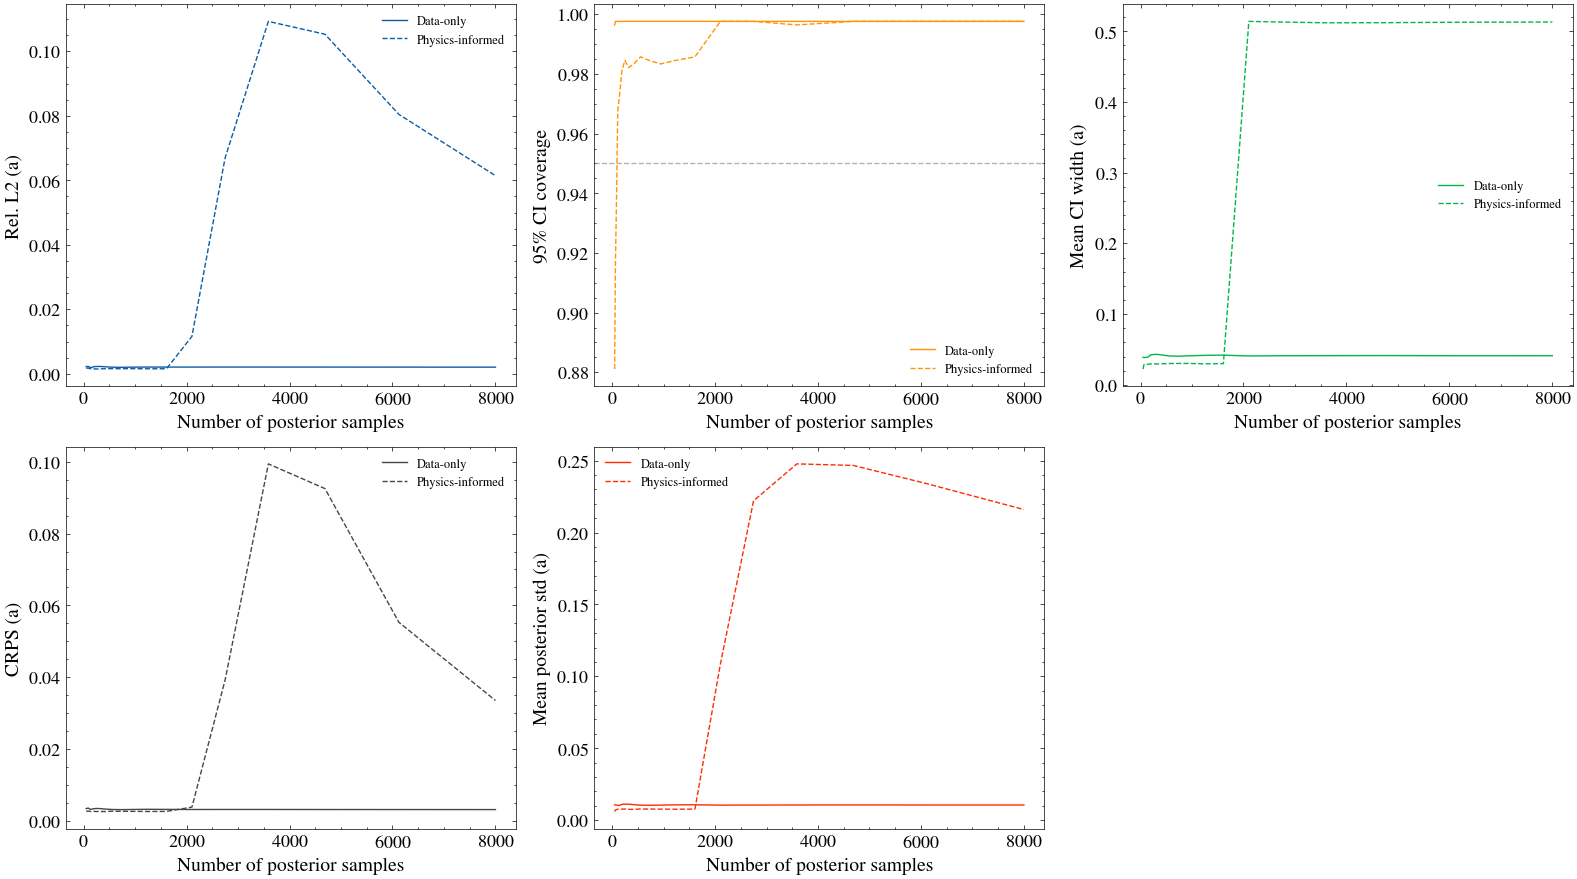

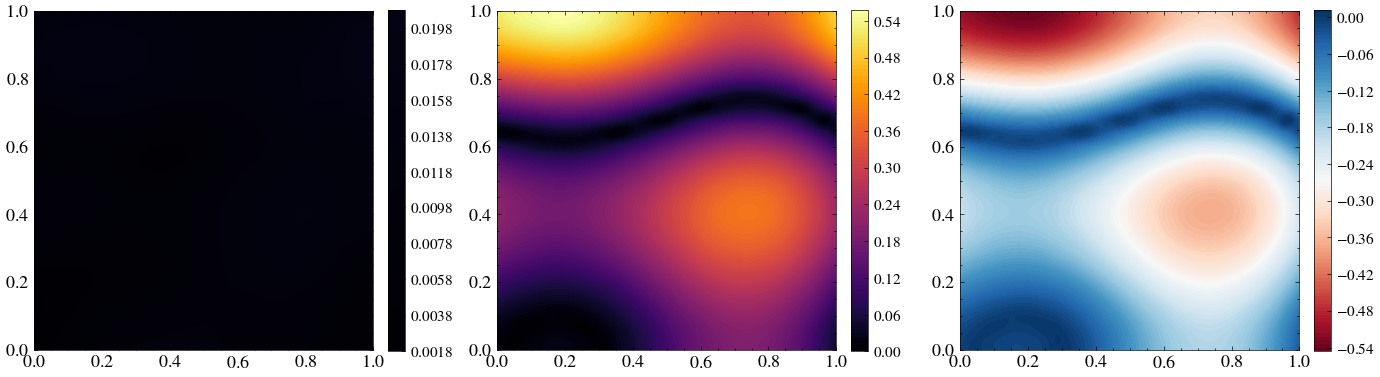

/workspace/experiments/experiment_utils/_plotting.py:576: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, framealpha=0.3, facecolor='white', edgecolor='black')


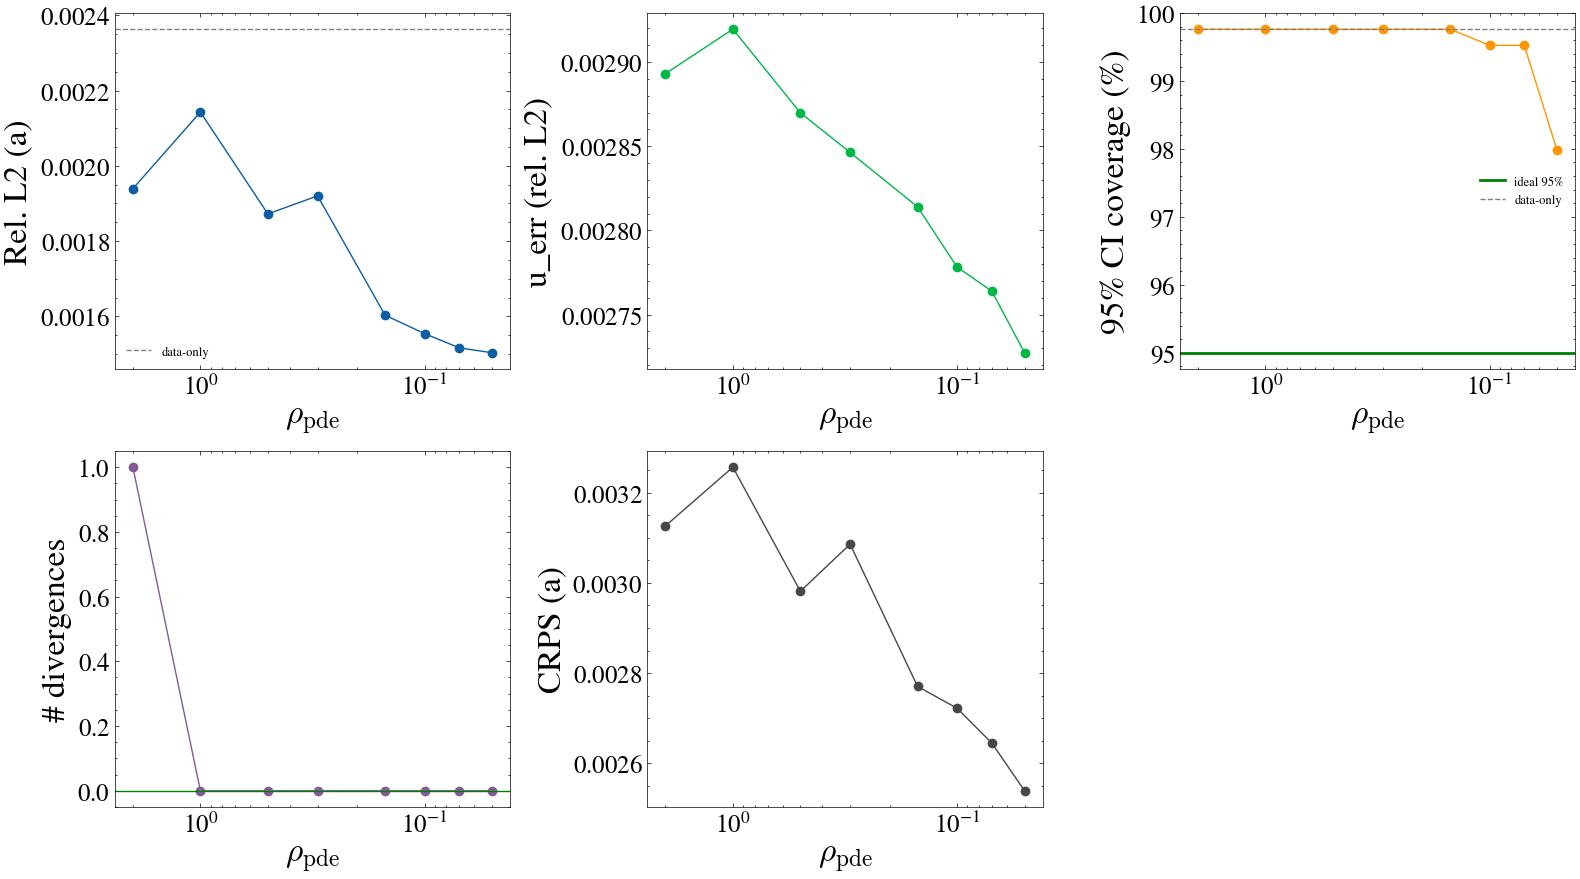

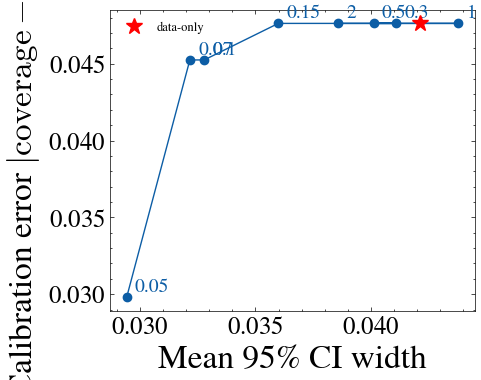

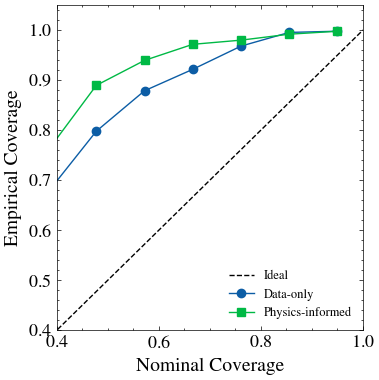

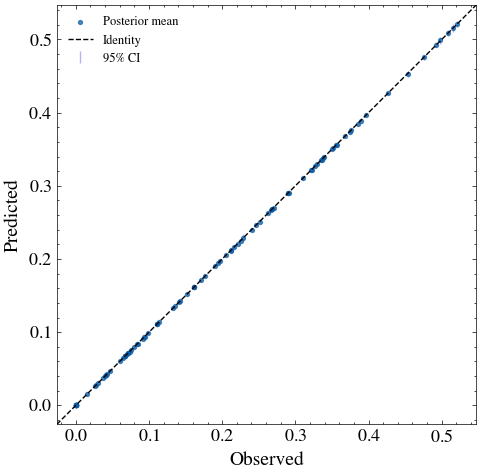

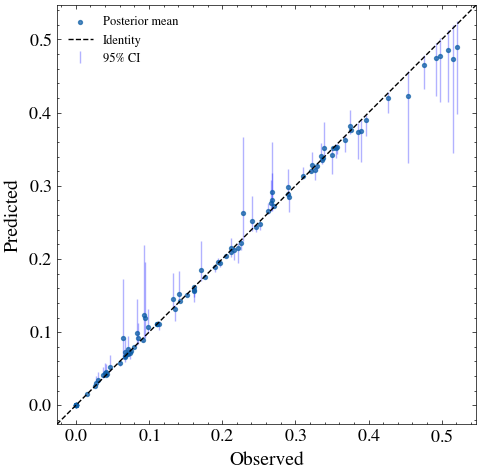

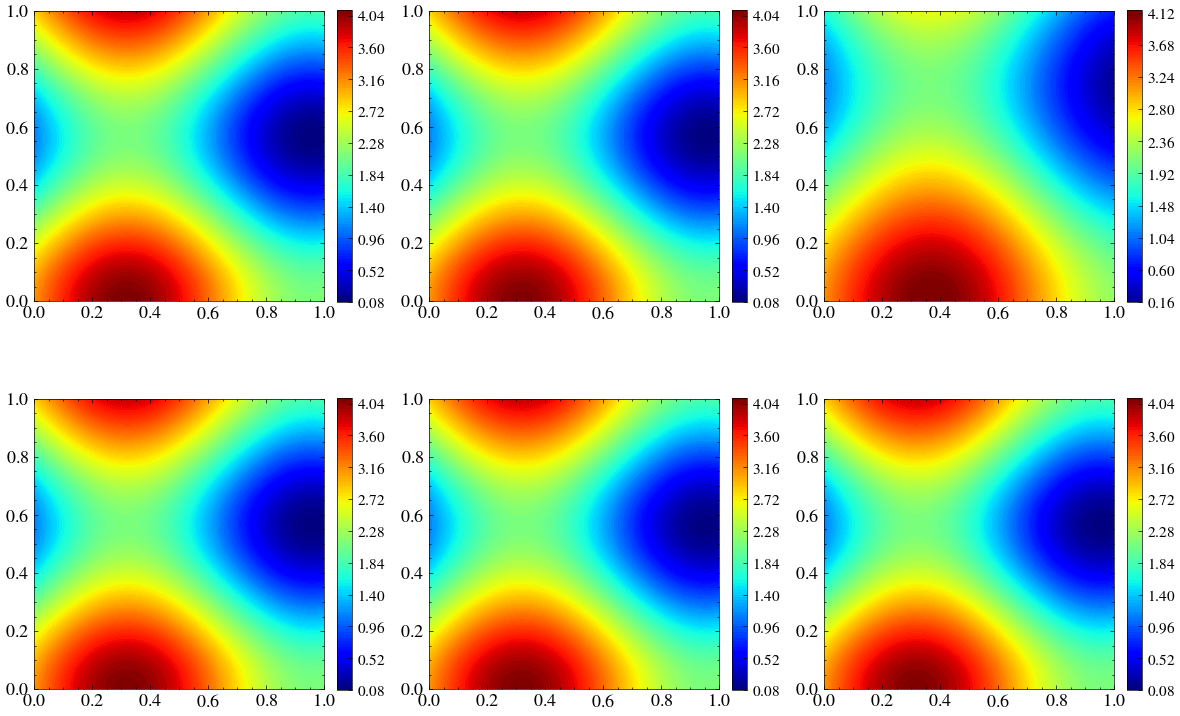

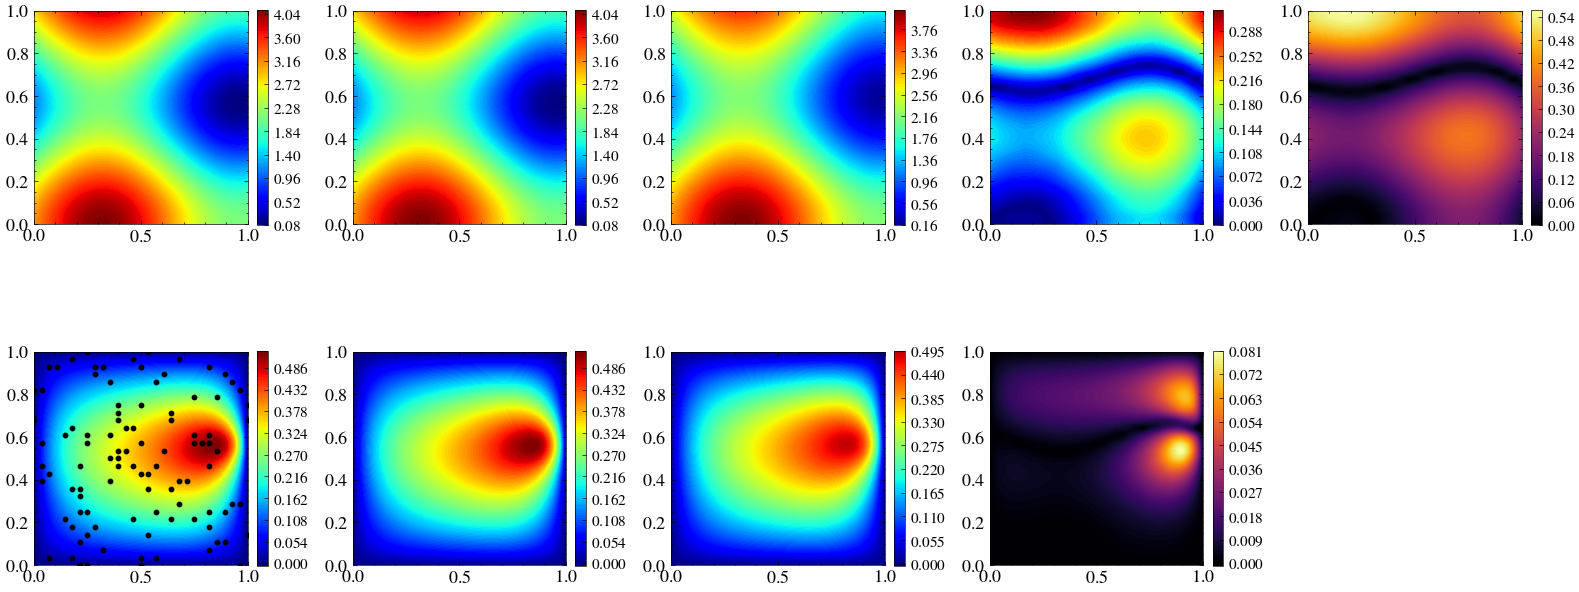

Per-dimension diagnostics:
 dim       ESS     R-hat        mean         std
   0       2.0   13.8542      0.4842      0.0880
   1       2.0   11.8918     -0.0727      0.0436
   2       2.1    3.8890      0.0315      0.0305
   3       2.0    8.7805     -0.3454      0.1048
   4       2.1    5.9175     -0.5420      0.0866
   5       2.0   22.1386     -0.6749      0.1722

  RELIABILITY (physics): [FAIL] ESS_min=2.0 < 10; R-hat_max=22.139 > 1.2
  RELIABILITY (data-only): [PASS] All diagnostics within thresholds


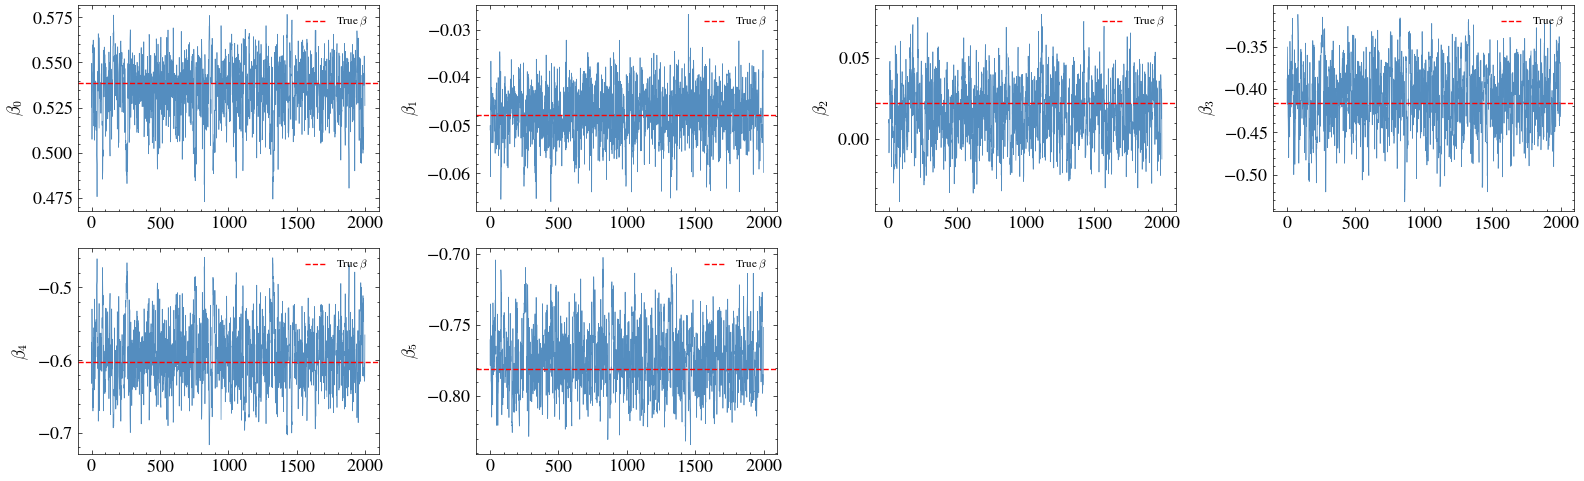

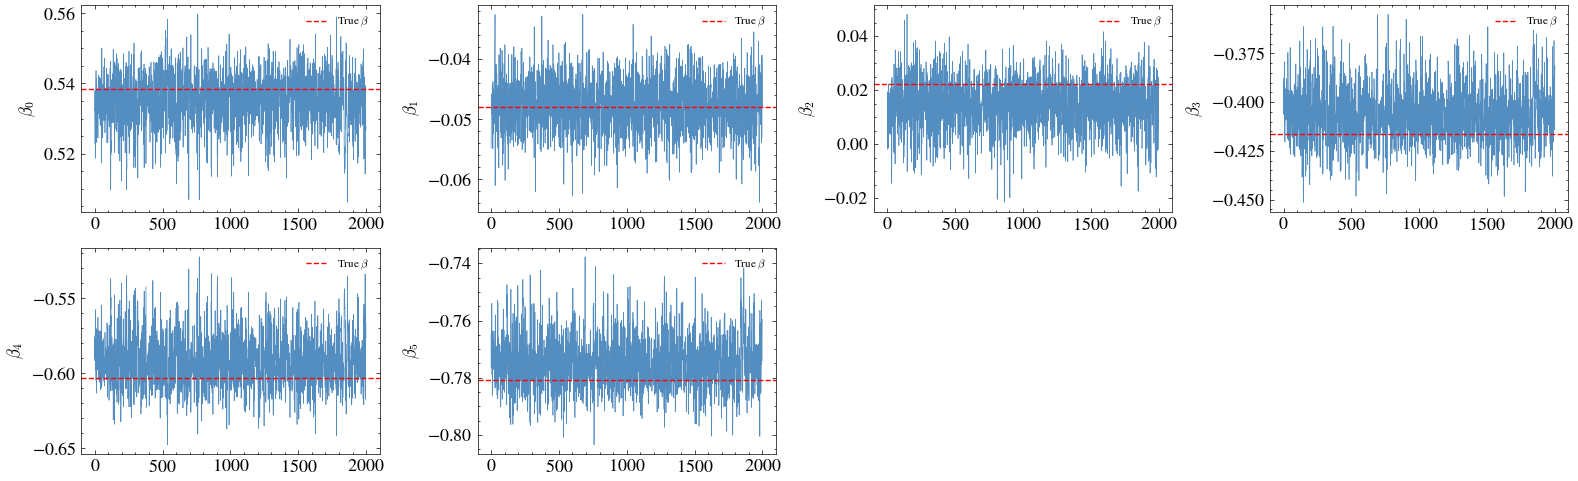

Spearman rho (data-only): 0.255, p = 6.59e-14
Spearman rho (physics): 0.999, p = 0.00e+00


In [12]:
from results_schema import ExperimentResult
from datetime import datetime

for SEED in SEEDS:
    _t_total_start = time.time()
    print(f"\n{'='*70}")
    print(f"SEED = {SEED}")
    print(f"{'='*70}")

    rng = random.PRNGKey(SEED)
    rng, key = random.split(rng)

    FIGURE_DIR = Path(f'figures/physics_darcy_continuous/test{TEST_IDX}/seed_{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    # ---- Observations ----
    obs_indices = problem.sample_observation_indices(n_points, N_OBS, 'random', key)
    obs_data = problem.prepare_observations(
        sample_indices=[TEST_IDX], obs_indices=obs_indices,
    )
    x_full = obs_data['x_full']
    x_obs = obs_data['x_obs']
    u_obs = obs_data['u_obs']
    a_true = obs_data['a_true']
    u_true = obs_data['u_true']
    a_true_np = np.array(a_true[0, :, 0])

    beta_true = problem.models['enc'].apply({'params': params['enc']}, a_true)[0]

    # ---- Prior Predictive ----
    prior_a_samples, prior_metrics, rng = sample_unconditional_prior(
        problem, params, x_full, a_true_np, rng,
    )
    prior_a_std = np.std(prior_a_samples, axis=0)
    print(f"Prior predictive: a_err={prior_metrics['a_err']:.4f}, "
          f"CRPS={prior_metrics['crps_a']:.4f}, cov95={prior_metrics['coverage_95']:.4f}")

    # ---- Build per-seed models ----
    log_likelihood_fn = make_gaussian_log_likelihood(problem, params, mollifier, x_obs, u_obs)
    numpyro_model_data_only = make_numpyro_model(d, log_prior_fn, log_likelihood_fn)
    numpyro_model_physics = make_numpyro_model_physics(d, log_prior_fn, log_likelihood_fn, log_pde_fn)

    # ---- MAP Baseline ----
    map_result = run_map_estimation(problem, params, x_obs, u_obs, x_full, inv_config, rng)
    beta_map = map_result['beta_map']
    a_map = map_result['a_map']
    u_map = map_result['u_map']
    _map_time_s = map_result['time_s']
    rng = map_result['rng']

    rmse_map_a = rmse(a_map, a_true[0])
    rmse_map_u = rmse(u_map, u_true[0])
    print(f"\nMAP RMSE: a={rmse_map_a:.6f}, u={rmse_map_u:.6f}")

    from src.utils.PlotFigure import Plot
    h = map_result['loss_history']
    Plot.show_loss(
        [h['total'], h['weighted_pde'], h['weighted_data']],
        ['Total', f'PDE (x{inv_config.loss_weights.pde})', f'Data (x{inv_config.loss_weights.data})'],
        save_path=str(FIGURE_DIR / 'map_loss_curves.png'),
    )

    # ---- Sigma Tuning ----
    def _model_factory(sigma):
        def _model():
            numpyro_model_data_only(sigma=sigma)
        return _model

    def _decode_fn(beta_samples):
        a_preds = []
        for i in range(len(beta_samples)):
            beta_i = beta_samples[i:i+1]
            preds = problem.predict_from_beta(params, jnp.array(beta_i), x_full)
            a_preds.append(np.array(preds['a_pred'][0, :, 0]))
        return np.stack(a_preds)

    rng, tune_key = jax.random.split(rng)
    SIGMA, _ = tune_sigma(
        model_fn_factory=_model_factory,
        beta_mode=beta_mode,
        sigma_candidates=[0.005, 0.01, 0.02, 0.04, 0.08, 0.15],
        rng_key=tune_key,
        decode_fn=_decode_fn,
        a_true=np.array(a_true[0, :, 0]),
        pilot_warmup=2000,
        pilot_samples=500,
        pilot_chains=2,
    )
    print(f"Sigma (tuned): {SIGMA:.6f}")

    # ---- Data-Only MCMC Full Run ----
    print(f"Data-only MCMC: {NUM_WARMUP} warmup, {NUM_SAMPLES} samples, sigma={SIGMA}, {NUM_CHAINS} chains ({CHAIN_METHOD})")

    nuts_cfg = recommended_nuts_config(d, SIGMA)
    rng, mcmc_key = random.split(rng)
    mcmc_do, timing_do = run_mcmc(
        numpyro_model_data_only, {"beta": beta_mode}, {"sigma": SIGMA}, mcmc_key,
        NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
    )
    mcmc_do.print_summary()

    diag_do = extract_mcmc_diagnostics(mcmc_do, sample_name="beta", total_samples=NUM_CHAINS * NUM_SAMPLES)
    a_do_np, u_do_np = decode_posterior_batched(problem, params, diag_do['samples'], x_full)

    metrics_do = compute_standard_metrics(a_do_np, a_true_np)
    a_std_do = np.std(a_do_np, axis=0)

    u_true_np = np.array(u_true[0, :, 0])
    u_err_do = float(np.linalg.norm(np.mean(u_do_np, axis=0) - u_true_np) / (np.linalg.norm(u_true_np) + 1e-12))

    print(f"Data-only: a_err={metrics_do['a_err']:.4f}  u_err={u_err_do:.4f}  "
          f"coverage={metrics_do['coverage_95']:.2%}  CRPS={metrics_do['crps_a']:.6f}")

    # ---- Physics-Informed Full Run ----
    print(f"Physics MCMC: rho_pde={BEST_RHO_PDE}, {NUM_WARMUP} warmup, {NUM_SAMPLES} samples, {NUM_CHAINS} chains")

    rng, mcmc_key_phys = random.split(rng)
    mcmc_phys, timing_phys = run_mcmc(
        numpyro_model_physics, {"beta": beta_mode},
        {"sigma": SIGMA, "rho_pde": BEST_RHO_PDE}, mcmc_key_phys,
        NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
    )

    diag_phys = extract_mcmc_diagnostics(mcmc_phys, sample_name="beta", total_samples=NUM_CHAINS * NUM_SAMPLES)
    a_phys_np, u_phys_np = decode_posterior_batched(problem, params, diag_phys['samples'], x_full)

    metrics_phys = compute_standard_metrics(a_phys_np, a_true_np)
    a_std_phys = np.std(a_phys_np, axis=0)

    u_err_phys = float(np.linalg.norm(np.mean(u_phys_np, axis=0) - u_true_np) / (np.linalg.norm(u_true_np) + 1e-12))

    print(f"Physics: a_err={metrics_phys['a_err']:.4f}  u_err={u_err_phys:.4f}  "
          f"coverage={metrics_phys['coverage_95']:.2%}  CRPS={metrics_phys['crps_a']:.6f}")

    # ---- Chi2 PPC ----
    u_obs_np = np.array(u_obs[0, :, 0])
    u_pred_at_obs_do = u_do_np[:, np.array(obs_indices)]
    u_pred_at_obs_phys = u_phys_np[:, np.array(obs_indices)]
    chi2_do, pval_do = chi2_ppc(u_obs_np, u_pred_at_obs_do, SIGMA)
    chi2_phys, pval_phys = chi2_ppc(u_obs_np, u_pred_at_obs_phys, SIGMA)
    print(f"  Chi2 PPC (data-only): chi2={chi2_do:.2f}, p={pval_do:.4f}")
    print(f"  Chi2 PPC (physics):   chi2={chi2_phys:.2f}, p={pval_phys:.4f}")

    # ---- Spearman error-std correlation ----
    spearman_rho_do, spearman_p_do = compute_error_std_correlation(
        a_true_np, np.mean(a_do_np, axis=0), a_std_do)
    spearman_rho_phys, spearman_p_phys = compute_error_std_correlation(
        a_true_np, np.mean(a_phys_np, axis=0), a_std_phys)

    # ---- Save Results ----
    sharpness_do = float(np.mean(a_std_do))
    sharpness_phys = float(np.mean(a_std_phys))

    do_result = {
        "sigma": SIGMA, "label": "data_only",
        "ess_min": diag_do['ess_min'], "rhat_max": diag_do['rhat_max'],
        "rhat_mean": diag_do['rhat_mean'], "n_div": diag_do['n_div'],
        "reliability_flag": diag_do['flag'],
        "reliability_explanation": diag_do['flag_explanation'],
        "a_err": metrics_do['a_err'], "u_err": u_err_do,
        "crps_a": metrics_do['crps_a'], "nll_a": metrics_do['nll_a'],
        "coverage": metrics_do['coverage_95'],
        "ci_width": metrics_do['ci_width'], "mean_std": sharpness_do,
        "cal_levels": metrics_do['cal_levels'],
        "cal_empirical": metrics_do['cal_empirical'],
        "chi2_ppc": chi2_do, "chi2_ppc_pvalue": pval_do,
        "map_a_err": float(rmse_map_a), "map_u_err": float(rmse_map_u),
        "spearman_rho_error_std": float(spearman_rho_do),
        "spearman_pvalue_error_std": float(spearman_p_do),
        "warmup_time_s": timing_do['warmup_time_s'],
        "sampling_time_s": timing_do['sampling_time_s'],
        "step_time_s": timing_do['step_time_s'],
    }

    phys_result = {
        "sigma": SIGMA, "label": "physics",
        "ess_min": diag_phys['ess_min'], "rhat_max": diag_phys['rhat_max'],
        "rhat_mean": diag_phys['rhat_mean'], "n_div": diag_phys['n_div'],
        "reliability_flag": diag_phys['flag'],
        "reliability_explanation": diag_phys['flag_explanation'],
        "a_err": metrics_phys['a_err'], "u_err": u_err_phys,
        "crps_a": metrics_phys['crps_a'], "nll_a": metrics_phys['nll_a'],
        "coverage": metrics_phys['coverage_95'],
        "ci_width": metrics_phys['ci_width'], "mean_std": sharpness_phys,
        "cal_levels": metrics_phys['cal_levels'],
        "cal_empirical": metrics_phys['cal_empirical'],
        "chi2_ppc": chi2_phys, "chi2_ppc_pvalue": pval_phys,
        "map_a_err": float(rmse_map_a), "map_u_err": float(rmse_map_u),
        "spearman_rho_error_std": float(spearman_rho_phys),
        "spearman_pvalue_error_std": float(spearman_p_phys),
        "warmup_time_s": timing_phys['warmup_time_s'],
        "sampling_time_s": timing_phys['sampling_time_s'],
        "step_time_s": timing_phys['step_time_s'],
    }

    experiment = ExperimentResult(
        experiment="physics",
        problem="darcy_continuous",
        experiment_type="comparison",
        seed=SEED,
        test_idx=TEST_IDX,
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        conditions={
            "data_only": build_mcmc_result(do_result, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS),
            "physics": build_mcmc_result(phys_result, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS),
        },
        prior=build_prior_result(prior_metrics),
        map_time_s=_map_time_s,
        total_time_s=time.time() - _t_total_start,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")


    # ---- Plots ----
    plot_metrics_comparison_table(
        {
            'RMSE (a)': float(rmse(jnp.array(np.mean(a_do_np, axis=0)), jnp.array(a_true_np))),
            'Rel. L2 (a)': metrics_do['a_err'],
            'Rel. L2 (u)': u_err_do,
            'CRPS (a)': metrics_do['crps_a'],
            '95% Coverage': metrics_do['coverage_95'],
            'CI Width (a)': metrics_do['ci_width'],
            'Sharpness (mean std)': sharpness_do,
            'ESS min': diag_do['ess_min'],
            'Divergences': diag_do['n_div'],
        },
        {
            'RMSE (a)': float(rmse(jnp.array(np.mean(a_phys_np, axis=0)), jnp.array(a_true_np))),
            'Rel. L2 (a)': metrics_phys['a_err'],
            'Rel. L2 (u)': u_err_phys,
            'CRPS (a)': metrics_phys['crps_a'],
            '95% Coverage': metrics_phys['coverage_95'],
            'CI Width (a)': metrics_phys['ci_width'],
            'Sharpness (mean std)': sharpness_phys,
            'ESS min': diag_phys['ess_min'],
            'Divergences': diag_phys['n_div'],
        },
        title=f'Darcy Continuous seed={SEED} (sigma={SIGMA}, rho_pde={BEST_RHO_PDE})',
    )

    # Significance Tests
    def _crps_a(s, t): return float(np.mean(crps_ensemble(s, t)))
    def _coverage_95(s, t):
        _, emp = compute_calibration(s, t, np.array([0.95]))
        return float(emp[0])
    def _ci_width(s, t): return ci_width_95(s)

    rng_bs = np.random.default_rng(2)
    diff_crps_a = bootstrap_metric_difference_ci(a_do_np, a_phys_np, a_true_np, _crps_a, rng=rng_bs)
    diff_cov = bootstrap_metric_difference_ci(a_do_np, a_phys_np, a_true_np, _coverage_95, rng=rng_bs)
    diff_width = bootstrap_metric_difference_ci(a_do_np, a_phys_np, a_true_np, _ci_width, rng=rng_bs)

    format_significance_table({
        'CRPS (a) diff (DO - Phys)': diff_crps_a,
        'Coverage 95% diff (DO - Phys)': diff_cov,
        'CI Width diff (DO - Phys)': diff_width,
    }, title=f'Darcy Continuous seed={SEED} -- RQ2: Physics vs Data-Only (Bootstrap)')

    # Metric Convergence
    conv_do = compute_metric_convergence(a_do_np, a_true_np)
    conv_phys = compute_metric_convergence(a_phys_np, a_true_np)
    plot_metric_convergence(
        [conv_do, conv_phys],
        labels=['Data-only', 'Physics-informed'],
        save_path=FIGURE_DIR / 'metric_convergence.png',
    )

    # Field plots
    x_np = np.array(x_full[0])

    plot_std_comparison(
        x_np,
        std_data_only=a_std_do,
        std_physics=a_std_phys,
        grid_shape=(29, 29),
        save_path=FIGURE_DIR / 'std_comparison.png',
    )

    plot_rho_sweep(
        sweep_results,
        _sweep_data_only_baseline,
        save_path=FIGURE_DIR / 'rho_sweep.png',
    )

    plot_sharpness_calibration_tradeoff(
        sweep_results,
        _sweep_data_only_baseline,
        save_path=FIGURE_DIR / 'sharpness_calibration_tradeoff.png',
    )

    with plt.style.context(_use_science_style()):
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Ideal')
        ax.plot(metrics_do['cal_levels'], metrics_do['cal_empirical'], 'o-', markersize=6, label='Data-only')
        ax.plot(metrics_phys['cal_levels'], metrics_phys['cal_empirical'], 's-', markersize=6, label='Physics-informed')
        ax.set_xlabel('Nominal Coverage', fontsize=14)
        ax.set_ylabel('Empirical Coverage', fontsize=14)
        ax.tick_params(labelsize=13)
        ax.set_xlim(0.4, 1.0)
        ax.set_ylim(0.4, 1.05)
        ax.legend(fontsize=9, framealpha=0.3, facecolor='white', edgecolor='black')
        plt.tight_layout()
        fig.savefig(FIGURE_DIR / 'calibration_overlay.png', dpi=200, bbox_inches='tight')
        plt.show()

    plot_posterior_predictive(
        u_obs_np, u_pred_at_obs_do,
        obs_label='u observed',
        save_path=FIGURE_DIR / 'posterior_predictive_data_only.png',
    )
    plot_posterior_predictive(
        u_obs_np, u_pred_at_obs_phys,
        obs_label='u observed',
        save_path=FIGURE_DIR / 'posterior_predictive_physics.png',
    )

    plot_posterior_gallery(
        x_np, a_phys_np, grid_shape=(29, 29),
        a_true=a_true_np, n_show=6,
        save_path=FIGURE_DIR / 'posterior_gallery_physics.png',
    )

    a_map_np = np.array(a_map[:, 0])
    plot_field_comparison(
        x_np, a_true_np, a_map_np, np.mean(a_phys_np, axis=0), a_std_phys,
        grid_shape=(29, 29),
        u_true=u_true_np,
        u_map=np.array(u_map[:, 0]),
        u_mean=np.mean(u_phys_np, axis=0),
        u_std=np.std(u_phys_np, axis=0),
        obs_coords=np.array(x_obs[0]),
        save_path=FIGURE_DIR / 'field_comparison_physics.png',
    )

    # Diagnostics
    print_dimension_diagnostics(np.array(diag_phys['samples']), diag_phys['ess'], diag_phys['rhat'])
    print(f"\n  RELIABILITY (physics): [{diag_phys['flag']}] {diag_phys['flag_explanation']}")
    print(f"  RELIABILITY (data-only): [{diag_do['flag']}] {diag_do['flag_explanation']}")

    beta_true_np = np.array(beta_true)
    beta_all_chains_do = np.array(mcmc_do.get_samples(group_by_chain=True)["beta"])
    plot_trace(beta_all_chains_do[0], beta_true_np, num_warmup=0,
               save_path=FIGURE_DIR / 'trace_plots_data_only.png')

    beta_phys_by_chain = np.array(mcmc_phys.get_samples(group_by_chain=True)["beta"])
    plot_trace(beta_phys_by_chain[0], beta_true_np, num_warmup=0,
               save_path=FIGURE_DIR / 'trace_plots_physics.png')

    spearman_rho_do, spearman_p_do = compute_error_std_correlation(
        a_true_np, np.mean(a_do_np, axis=0), a_std_do,
        save_path=FIGURE_DIR / 'error_vs_std_data_only.png',
    )
    print(f'Spearman rho (data-only): {spearman_rho_do:.3f}, p = {spearman_p_do:.2e}')

    spearman_rho_phys, spearman_p_phys = compute_error_std_correlation(
        a_true_np, np.mean(a_phys_np, axis=0), a_std_phys,
        save_path=FIGURE_DIR / 'error_vs_std_physics.png',
    )
    print(f'Spearman rho (physics): {spearman_rho_phys:.3f}, p = {spearman_p_phys:.2e}')

## Cross-Seed Aggregation Summary

In [13]:
results = load_cross_seed_results("physics", "darcy_continuous")
if len(results) > 1:
    print(f"Cross-Seed Summary ({len(results)} seeds: {[r.seed for r in results]})")
    for cond in list(results[0].conditions.keys()):
        print(f"\n--- {cond} ---")
        print(f"{'Metric':<16s}  {'Mean':>10s}  {'Std':>10s}  {'Min':>10s}  {'Max':>10s}")
        print("-" * 62)
        for m in ["a_err", "u_err", "crps_a", "nll_a", "coverage_95", "ci_width", "mean_std", "ess_min", "rhat_max", "n_div"]:
            try:
                s = cross_seed_metric_summary(results, metric=m, condition_key=cond)
                if s["mean"] is not None:
                    print(f"{m:<16s}  {s['mean']:>10.4f}  {s['std']:>10.4f}  {s['min']:>10.4f}  {s['max']:>10.4f}")
            except (AttributeError, KeyError, TypeError):
                pass
else:
    print(f"Only {len(results)} seed result(s) found - skipping cross-seed summary")

Cross-Seed Summary (18 seeds: [7, 7, 7, 7, 7, 7, 42, 42, 42, 42, 42, 42, 123, 123, 123, 123, 123, 123])

--- data_only ---
Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                 0.0333      0.0516      0.0017      0.1632
u_err                 0.0317      0.0383      0.0017      0.1208
crps_a                0.0469      0.0743      0.0029      0.2384
nll_a                -1.9934      1.4849     -3.6356      0.6223
coverage_95           0.9732      0.0522      0.8347      1.0000
ci_width              0.3849      0.4472      0.0395      1.3383
mean_std              0.0989      0.1143      0.0100      0.3395
ess_min             902.6478    861.4779     79.8117   2689.8224
rhat_max              1.0192      0.0208      1.0015      1.0643
n_div                23.8889     26.5571      0.0000     66.0000

--- physics ---
Metric                  Mean         Std         Min         Max
-----------------